# Credit Risk Prediction

In [1]:
import os
import matplotlib.pyplot as plt

PROJECT_ROOT_DIR = "."
PRJ_NAME = "credit_risk_prediction"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", PRJ_NAME)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." +fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


In [3]:
df = pd.read_csv(
    r"C:\Users\USER\ipnyb files\Machine Learning\Ensemble methods\datasets\credit_risk_dataset.csv"
)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


#### About The Dataset 
---

| Feature Name                     | Description                                  |
|----------------------------------|----------------------------------------------|
| person_age                       | Age                                          |
| person_income                    | Annual Income                                |
| person_home_ownership            | Home ownership                               |
| person_emp_length                | Employment length (in years)                 |
| loan_intent                      | Loan intent                                  |
| loan_grade                       | Loan grade                                   |
| loan_amnt                        | Loan amount                                  |
| loan_int_rate                    | Interest rate                                |
| loan_status                      | Loan status (0 = non-default, 1 = default)   |
| loan_percent_income              | Percent income                               |
| cb_person_default_on_file        | Historical default                           |
| cb_person_cred_hist_length       | Credit history length                        |

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [5]:
df.duplicated().sum()

np.int64(165)

In [6]:
df[df.duplicated(keep=False)]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
14,23,115000,RENT,2.0,EDUCATION,A,35000,7.90,0,0.30,N,4
238,22,183000,MORTGAGE,3.0,EDUCATION,A,1000,NaN,0,0.01,N,2
252,24,85000,RENT,5.0,MEDICAL,B,25000,10.62,0,0.29,N,4
591,26,20000,MORTGAGE,5.0,MEDICAL,A,4800,5.99,0,0.24,N,3
740,21,21600,OWN,NaN,VENTURE,A,7125,6.99,0,0.33,N,3
...,...,...,...,...,...,...,...,...,...,...,...,...
32010,42,39996,MORTGAGE,2.0,HOMEIMPROVEMENT,A,2500,5.42,0,0.06,N,12
32047,36,250000,RENT,2.0,DEBTCONSOLIDATION,A,20000,7.88,0,0.08,N,17
32172,49,120000,MORTGAGE,12.0,MEDICAL,B,12000,10.99,0,0.10,N,12
32259,39,40000,OWN,4.0,VENTURE,B,1000,10.37,0,0.03,N,16


In [7]:
dup_count = df.duplicated().sum()
total = len(df)

print(f"{(dup_count/total)*100}% of duplicate data")

0.506430127988705% of duplicate data


Since the percentage of the duplicates is less than 1% it is safe to drop these.

In [8]:
df = df.drop_duplicates(keep="last")
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(32416, 12)

In [10]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,31529.00000,32416.000000,29321.000000,32416.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.79051,9593.845632,11.017265,0.218688,0.170250,5.811297
std,6.354100,6.201558e+04,4.14549,6322.730241,3.241680,0.413363,0.106812,4.059030
min,20.000000,4.000000e+03,0.00000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.00000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.00000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.00000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.00000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [11]:
df.isna().mean().sort_values(ascending=False)

loan_int_rate                 0.095478
person_emp_length             0.027363
person_income                 0.000000
person_age                    0.000000
person_home_ownership         0.000000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

## Handle Missing values

In [12]:
# Summary statistics for loan_int_rate and person_emp_length

df[['loan_int_rate', 'person_emp_length']].describe()

,loan_int_rate,person_emp_length
count,29321.000000,31529.00000
mean,11.017265,4.79051
std,3.241680,4.14549
min,5.420000,0.00000
25%,7.900000,2.00000
50%,10.990000,4.00000
75%,13.470000,7.00000
max,23.220000,123.00000


In [13]:
df[['loan_int_rate', 'person_emp_length']].median()

loan_int_rate        10.99
person_emp_length     4.00
dtype: float64

Saving figure loan_int_rate and employment_years distribution


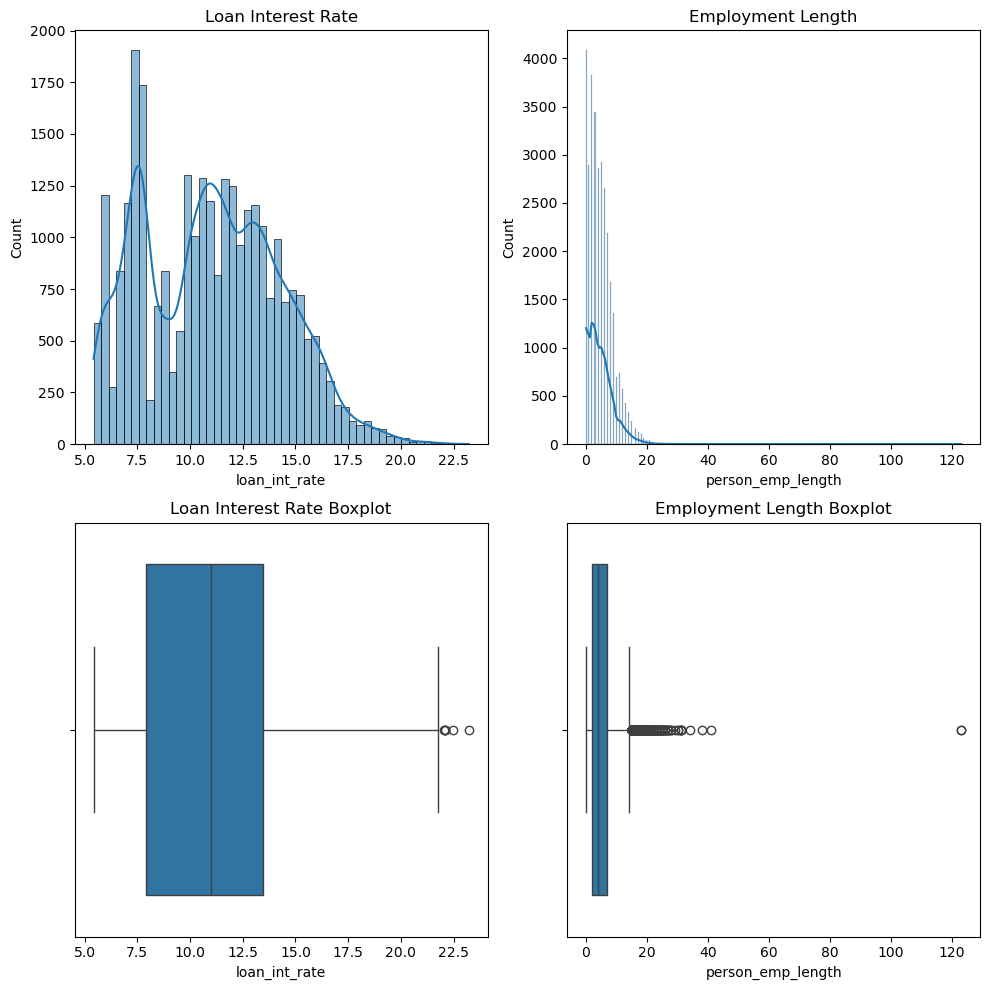

In [14]:
plt.figure(figsize=(10,10))

# 2 rows, 2 columns

# Histogram 1
plt.subplot(2, 2, 1)
sns.histplot(df['loan_int_rate'], kde=True)
plt.title('Loan Interest Rate')

# Histogram 2
plt.subplot(2, 2, 2)
sns.histplot(df['person_emp_length'], kde=True)
plt.title('Employment Length')

# Boxplot 1
plt.subplot(2, 2, 3)
sns.boxplot(x=df['loan_int_rate'])
plt.title('Loan Interest Rate Boxplot')

# Boxplot 2
plt.subplot(2, 2, 4)
sns.boxplot(x=df['person_emp_length'])
plt.title('Employment Length Boxplot')

plt.tight_layout()
save_fig("loan_int_rate and employment_years distribution")
plt.show()

In [15]:
df.columns  

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

Text(0.5, 1.0, 'Age ')

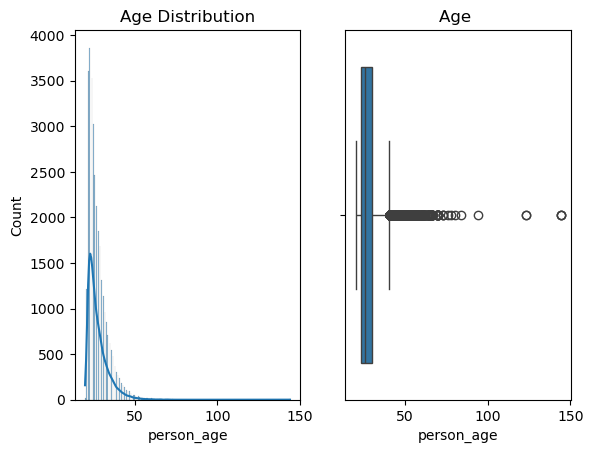

In [16]:
plt.subplot(1,2,1)
sns.histplot(df['person_age'], kde=True)
plt.title('Age Distribution')
plt.subplot(1,2,2)
sns.boxplot(x=df['person_age'])
plt.title('Age ')

In [17]:
df[['loan_int_rate', 'person_emp_length', 'person_age']].agg(['min', 'max'])

,loan_int_rate,person_emp_length,person_age
min,5.42,0.0,20
max,23.22,123.0,144


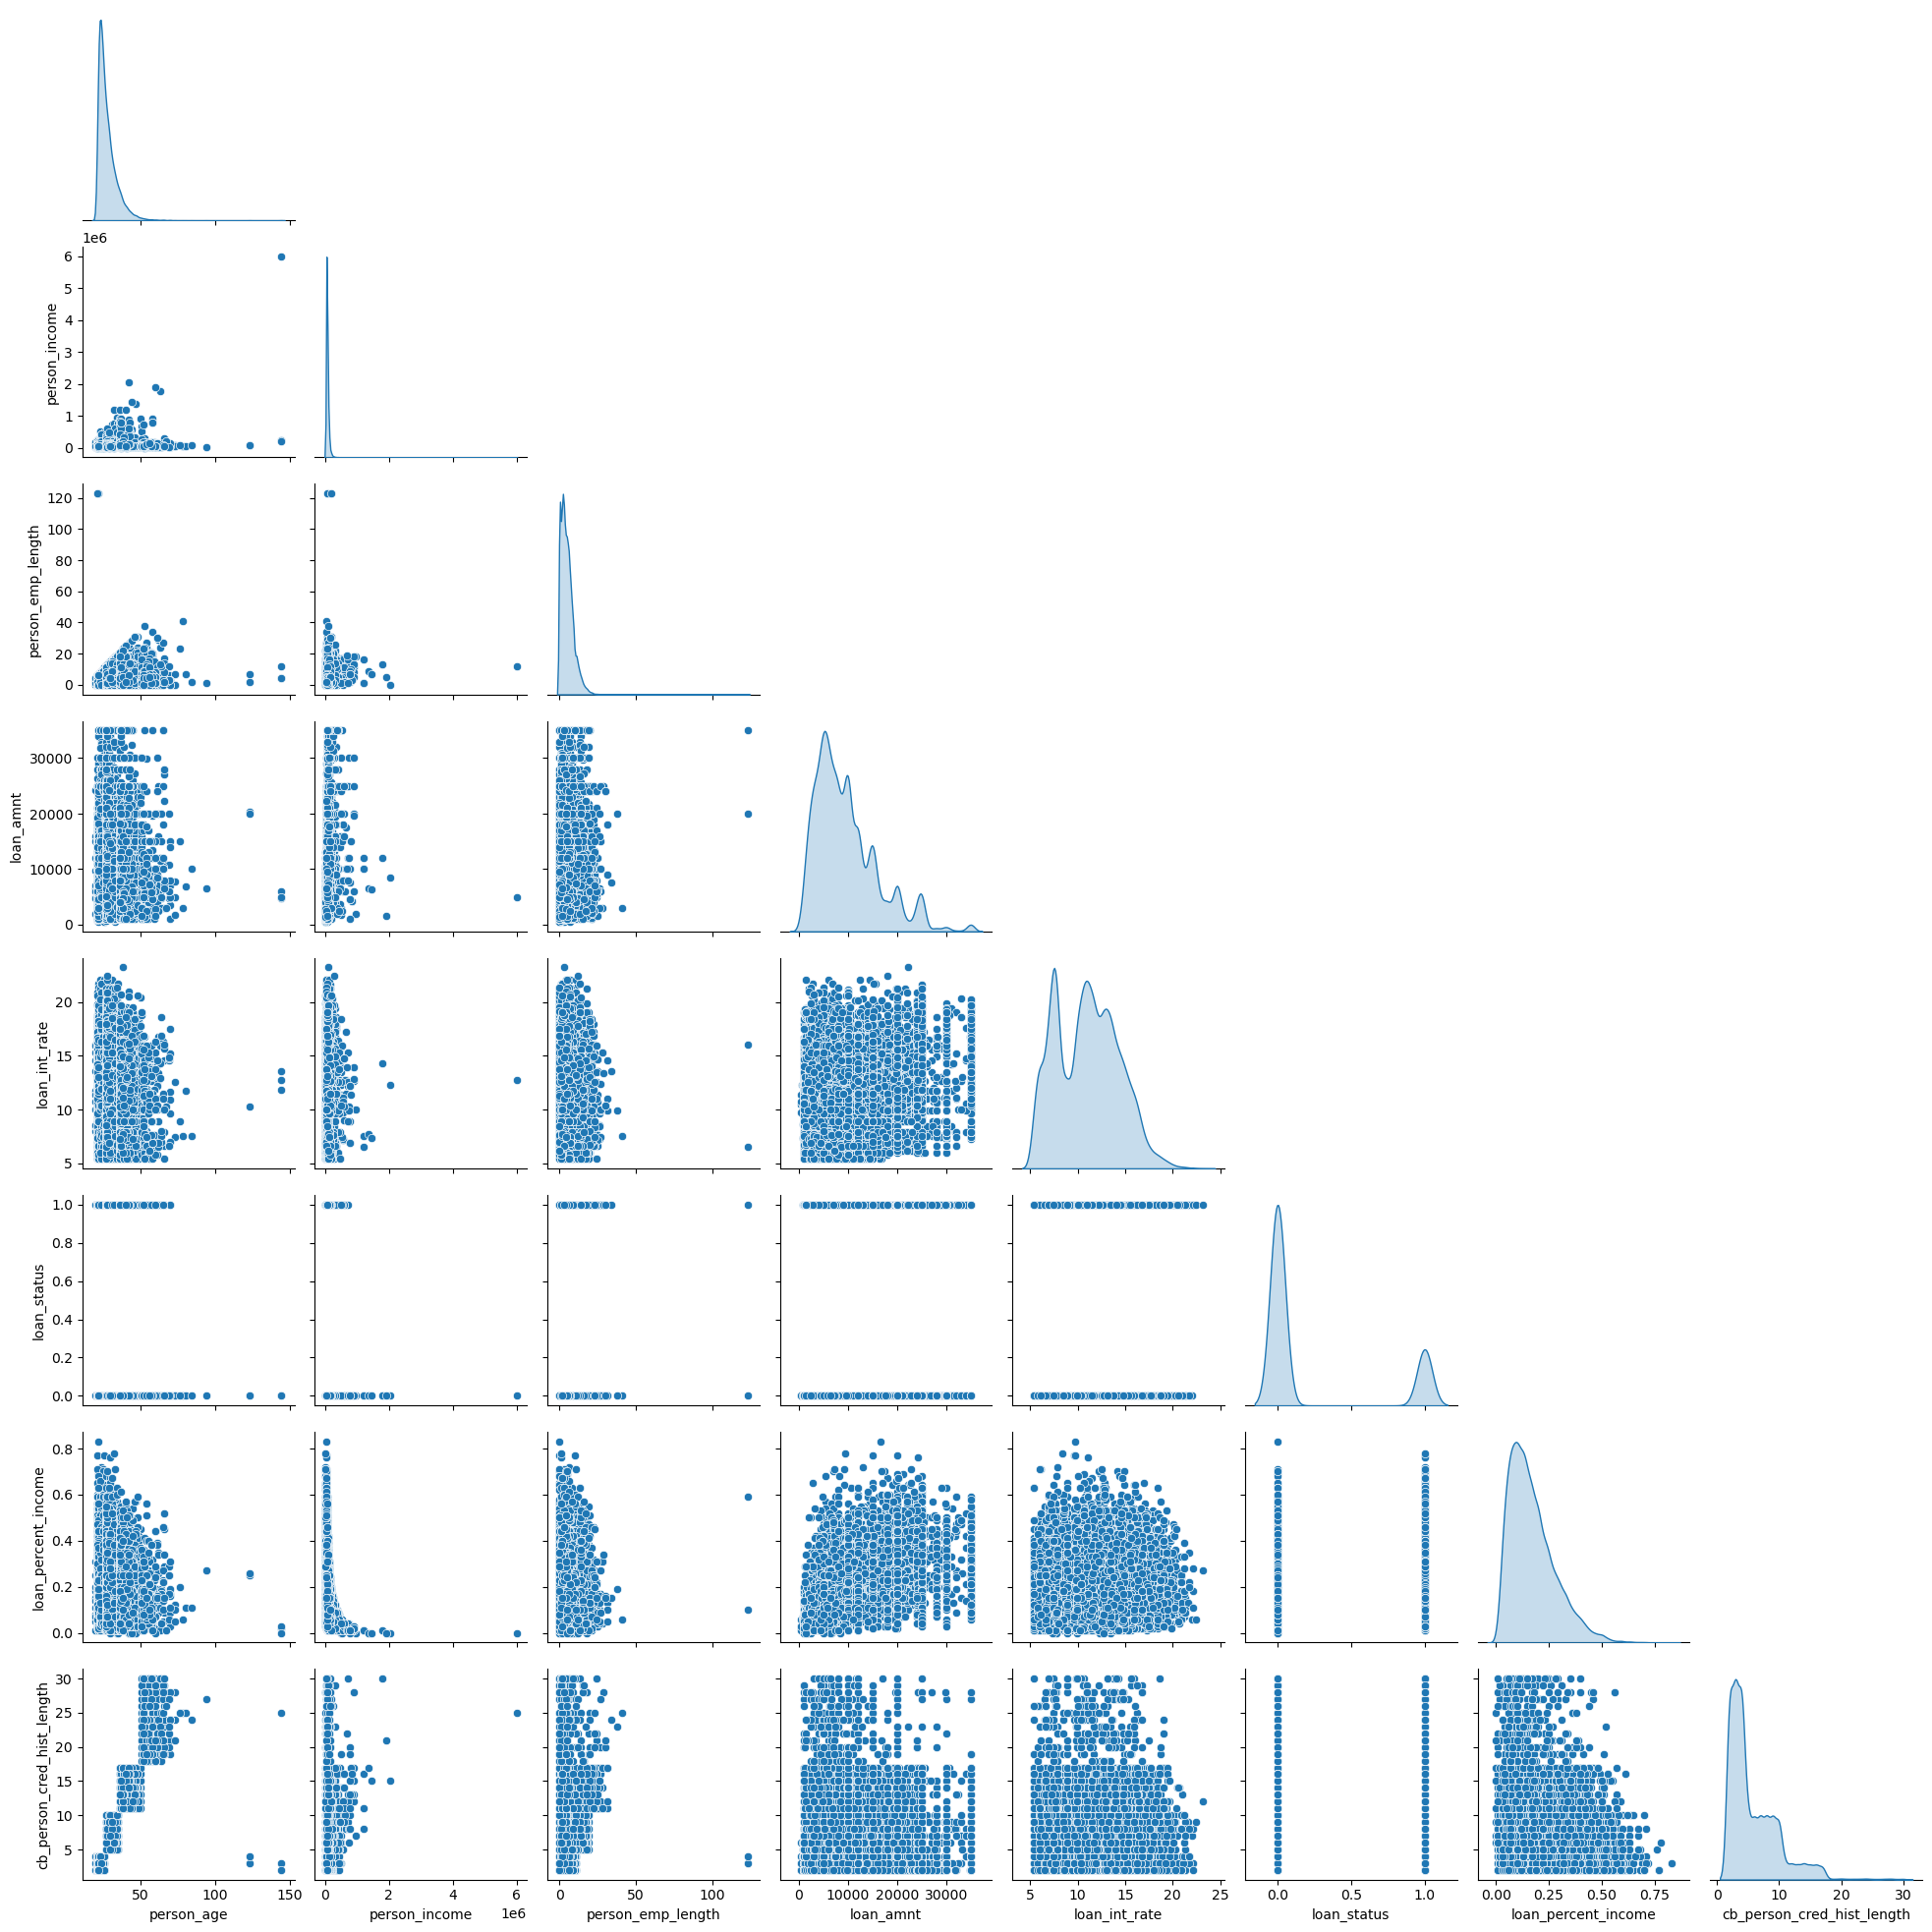

In [18]:
sns.pairplot(df, diag_kind='kde', corner=True)
plt.show()

In [19]:
df[['person_age', 'person_emp_length']][(df['person_age']>100) | (df['person_emp_length'] > 60)]

,person_age,person_emp_length
0,22,123.0
81,144,4.0
183,144,4.0
210,21,123.0
575,123,2.0
747,123,7.0
32297,144,12.0


In [20]:
df[(df['person_age']>100) | (df['person_emp_length'] > 60)]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [21]:
condition = (df['person_age'] > 100) | (df['person_emp_length'] > 60)

df = df.drop(df[condition].index)

In [22]:
df.shape

(32409, 12)

Saving figure illogical dropped loan_int_rate and employment_years distribution


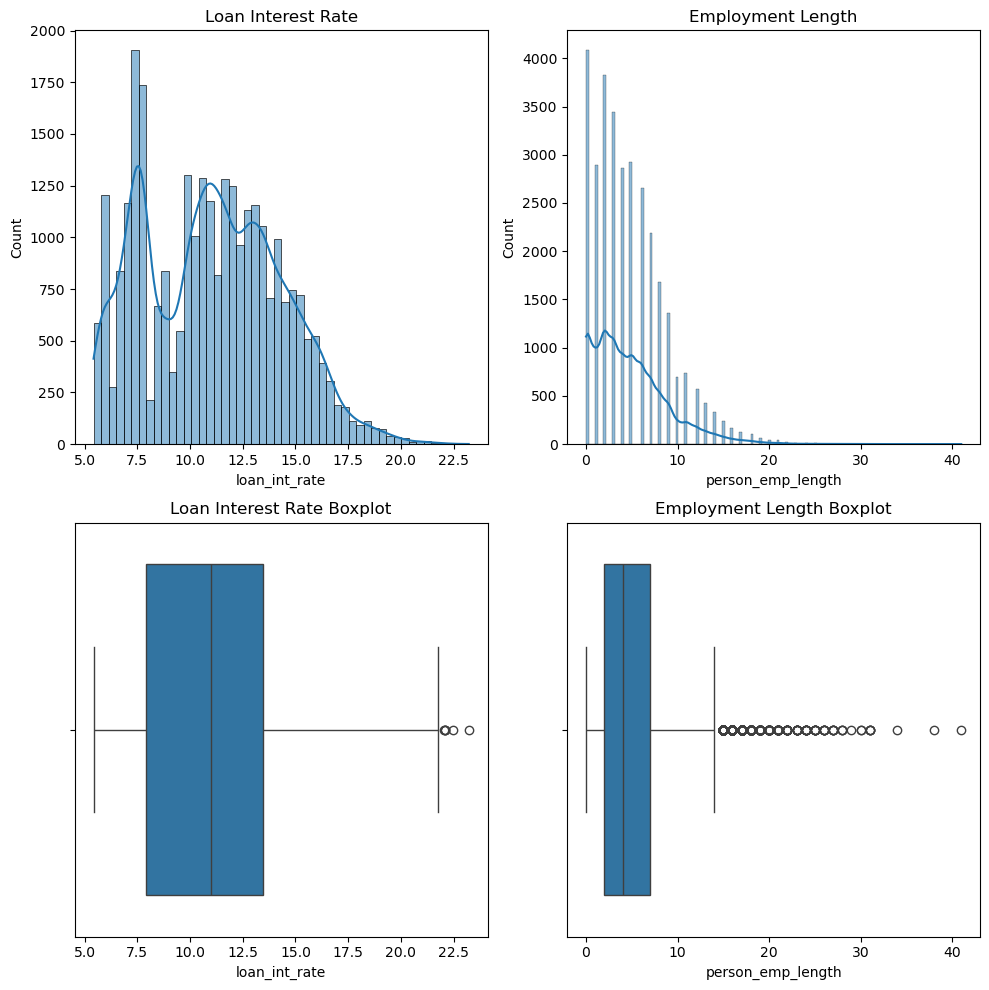

In [23]:
plt.figure(figsize=(10,10))

# 2 rows, 2 columns

# Histogram 1
plt.subplot(2, 2, 1)
sns.histplot(df['loan_int_rate'], kde=True)
plt.title('Loan Interest Rate')

# Histogram 2
plt.subplot(2, 2, 2)
sns.histplot(df['person_emp_length'], kde=True)
plt.title('Employment Length')

# Boxplot 1
plt.subplot(2, 2, 3)
sns.boxplot(x=df['loan_int_rate'])
plt.title('Loan Interest Rate Boxplot')

# Boxplot 2
plt.subplot(2, 2, 4)
sns.boxplot(x=df['person_emp_length'])
plt.title('Employment Length Boxplot')

plt.tight_layout()
save_fig("illogical dropped loan_int_rate and employment_years distribution")
plt.show()

In [24]:
(df['person_age'] < df['person_emp_length']).sum()

np.int64(0)

In [25]:
df[['person_age', 'person_emp_length']].sort_values(
    by=['person_emp_length', 'person_age'],
    ascending=[False, False]
).head(20)

,person_age,person_emp_length
32355,78,41.0
32515,53,38.0
32428,58,34.0
30914,48,31.0
31866,47,31.0
31867,46,31.0
32263,46,31.0
32539,61,30.0
32562,61,30.0
32480,62,29.0


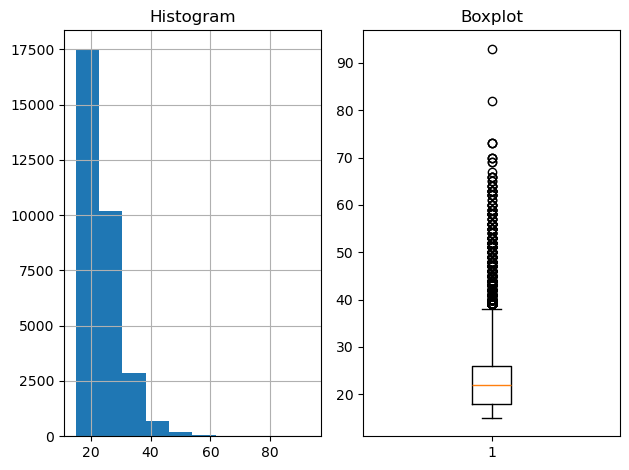

In [26]:
df['age_emp_diff'] = df['person_age'] - df['person_emp_length']

plt.figure()

# Histogram
plt.subplot(1, 2, 1)
df['age_emp_diff'].hist()
plt.title('Histogram')

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(df['age_emp_diff'].dropna())
plt.title('Boxplot')

plt.tight_layout()
plt.show()

In [27]:
df[['age_emp_diff', 'person_emp_length', 'person_age']].agg(['min', 'max'])

,age_emp_diff,person_emp_length,person_age
min,15.0,0.0,20
max,93.0,41.0,94


In [28]:
df[df['age_emp_diff'] == df['age_emp_diff'].min()][
    ['age_emp_diff', 'person_emp_length', 'person_age']
].sort_values(
    by=['person_age', 'person_emp_length', ],
    ascending=[True, True]
).head(20)

,age_emp_diff,person_emp_length,person_age
9,15.0,6.0,21
72,15.0,6.0,21
171,15.0,6.0,21
730,15.0,6.0,21
866,15.0,6.0,21
1039,15.0,6.0,21
1209,15.0,6.0,21
1814,15.0,6.0,21
1946,15.0,6.0,21
2092,15.0,6.0,21


In [29]:
df[df['age_emp_diff'] == df['age_emp_diff'].max()][
    ['age_emp_diff', 'person_emp_length', 'person_age']
].sort_values(
    by=['person_age', 'person_emp_length', ],
).head(20)

,age_emp_diff,person_emp_length,person_age
32416,93.0,1.0,94


In [30]:
original_df = df.drop(columns=['age_emp_diff'])

Now we have dropped the duplicates and the illogical data, like huge age and employment length, and copied the dataframe to a original_df for reuse.
Now we have to impute the missing values using MICE imputation. But before imputation we have to split and handle the outliers.

Before that let us explore the loan interest rate

Saving figure loan_intent and loan_interest comparison


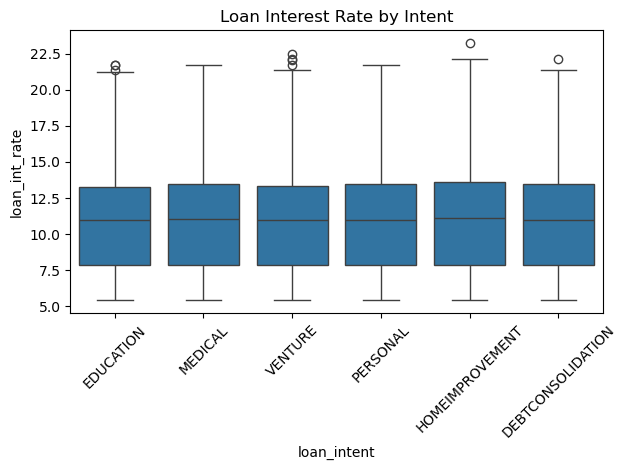

In [31]:
plt.figure()
sns.boxplot(x='loan_intent', y='loan_int_rate', data=df)
plt.xticks(rotation=45)
plt.title('Loan Interest Rate by Intent')
save_fig("loan_intent and loan_interest comparison")
plt.show()

In [32]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'age_emp_diff'],
      dtype='str')

In [33]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_emp_diff
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,16.0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,24.0
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,19.0
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,16.0
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,19.0


In [34]:
df.info()

<class 'pandas.DataFrame'>
Index: 32409 entries, 1 to 32580
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32409 non-null  int64  
 1   person_income               32409 non-null  int64  
 2   person_home_ownership       32409 non-null  str    
 3   person_emp_length           31522 non-null  float64
 4   loan_intent                 32409 non-null  str    
 5   loan_grade                  32409 non-null  str    
 6   loan_amnt                   32409 non-null  int64  
 7   loan_int_rate               29315 non-null  float64
 8   loan_status                 32409 non-null  int64  
 9   loan_percent_income         32409 non-null  float64
 10  cb_person_default_on_file   32409 non-null  str    
 11  cb_person_cred_hist_length  32409 non-null  int64  
 12  age_emp_diff                31522 non-null  float64
dtypes: float64(4), int64(5), str(4)
memory usage: 4

Saving figure loan_grade and loan_interest comparison


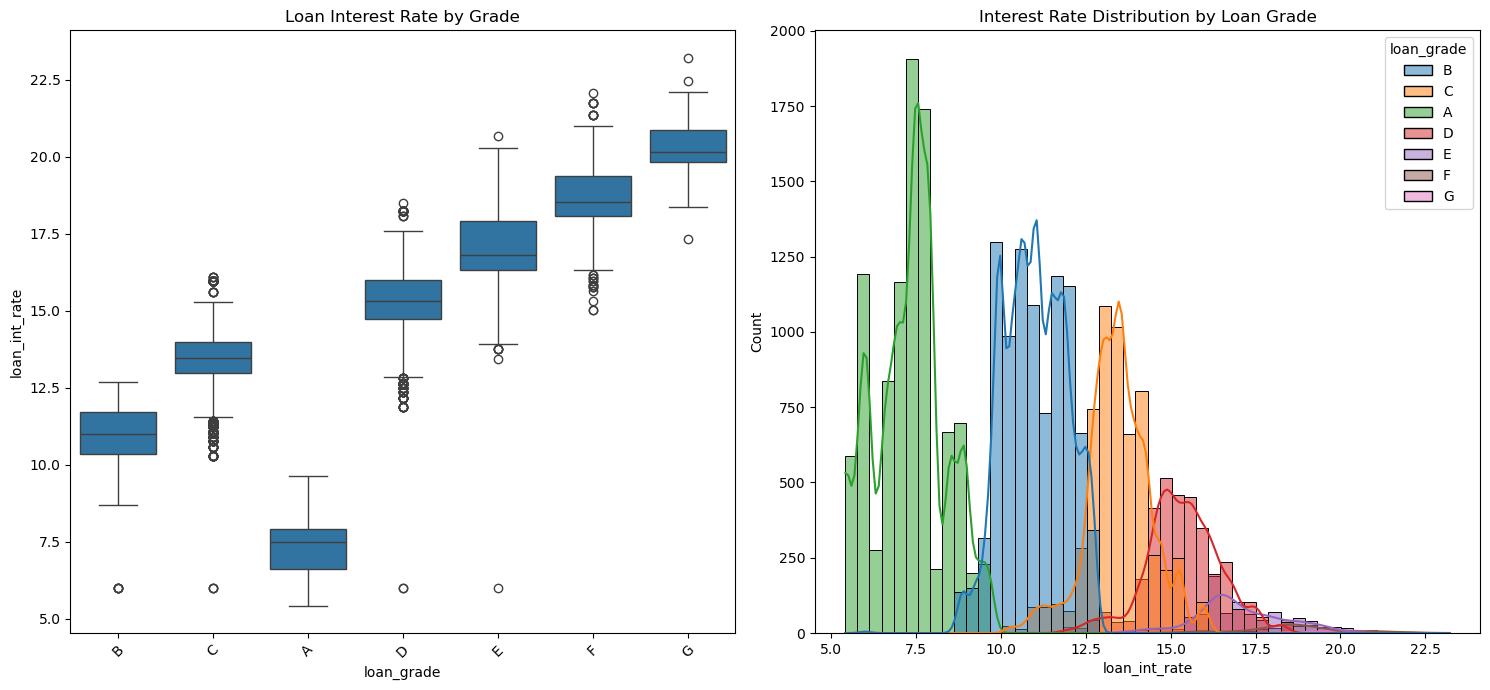

In [35]:
plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
sns.boxplot(x='loan_grade', y='loan_int_rate', data=df)
plt.xticks(rotation=45)
plt.title('Loan Interest Rate by Grade')


plt.subplot(1,2,2)
sns.histplot(data=df, x='loan_int_rate', hue='loan_grade', kde=True)
plt.title('Interest Rate Distribution by Loan Grade')

save_fig("loan_grade and loan_interest comparison")
plt.show()

This proves that loan_grade strongly segments loan_int_rate distributions. So for imputing the loan_int_rate, we can either take the median of each gropu or use the mice.

In [36]:
df.info()

<class 'pandas.DataFrame'>
Index: 32409 entries, 1 to 32580
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32409 non-null  int64  
 1   person_income               32409 non-null  int64  
 2   person_home_ownership       32409 non-null  str    
 3   person_emp_length           31522 non-null  float64
 4   loan_intent                 32409 non-null  str    
 5   loan_grade                  32409 non-null  str    
 6   loan_amnt                   32409 non-null  int64  
 7   loan_int_rate               29315 non-null  float64
 8   loan_status                 32409 non-null  int64  
 9   loan_percent_income         32409 non-null  float64
 10  cb_person_default_on_file   32409 non-null  str    
 11  cb_person_cred_hist_length  32409 non-null  int64  
 12  age_emp_diff                31522 non-null  float64
dtypes: float64(4), int64(5), str(4)
memory usage: 4

In [37]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df.loan_status)
train_enc = pd.get_dummies(train_df, columns=[
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
], drop_first=True)

test_enc = pd.get_dummies(test_df, columns=[
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
], drop_first=True)

In [38]:
imputer = IterativeImputer(random_state=42)

train_imputed = imputer.fit_transform(train_enc)
test_imputed = imputer.transform(test_enc)

In [39]:
train_imputed = pd.DataFrame(train_imputed, columns=train_enc.columns)
test_imputed = pd.DataFrame(test_imputed, columns=test_enc.columns)

In [40]:
train_imputed['loan_grade'] = train_df['loan_grade'].values
test_imputed['loan_grade'] = test_df['loan_grade'].values
imputed_full = pd.concat([train_imputed, test_imputed], ignore_index=True)

Saving figure data after MICE


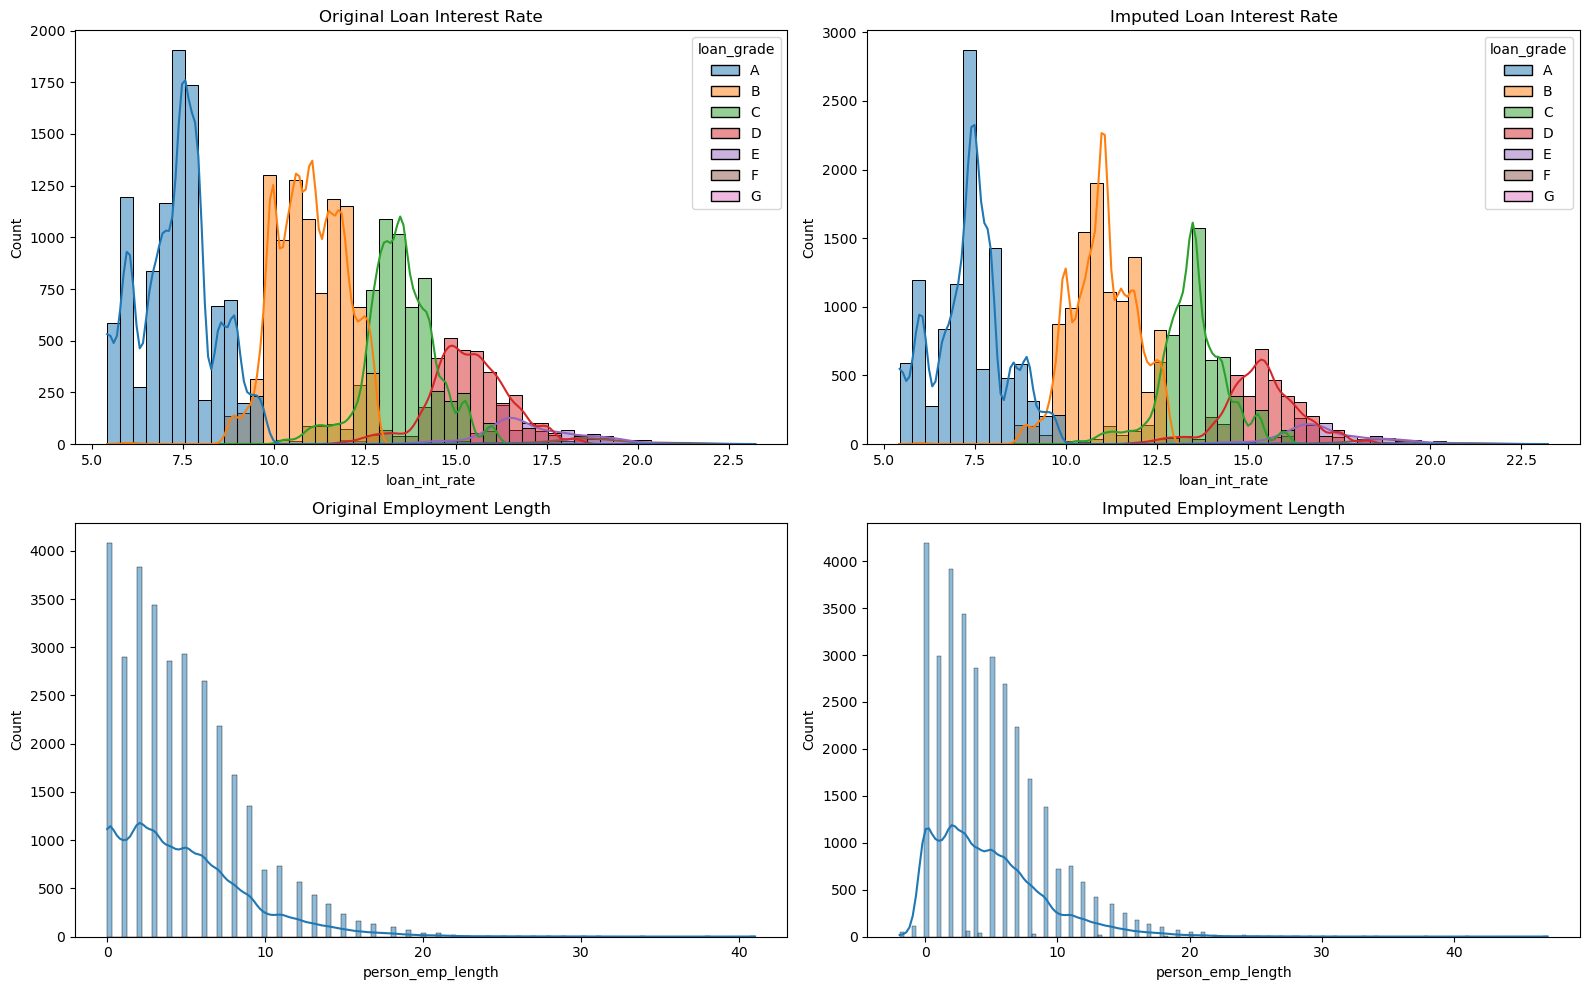

In [41]:
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

plt.figure(figsize=(16,10))

# -------------------
# 1. Original Loan Interest Rate
# -------------------
plt.subplot(2,2,1)
sns.histplot(data=df, x='loan_int_rate', hue='loan_grade', hue_order=grade_order, kde=True)
plt.title('Original Loan Interest Rate')

# -------------------
# 2. Imputed Loan Interest Rate
# -------------------
plt.subplot(2,2,2)
sns.histplot(data=imputed_full, x='loan_int_rate', hue='loan_grade', hue_order=grade_order, kde=True)
plt.title('Imputed Loan Interest Rate')

# -------------------
# 3. Original Employment Length
# -------------------
plt.subplot(2,2,3)
sns.histplot(data=df, x='person_emp_length', hue_order=grade_order, kde=True)
plt.title('Original Employment Length')

# -------------------
# 4. Imputed Employment Length
# -------------------
plt.subplot(2,2,4)
sns.histplot(data=imputed_full, x='person_emp_length', hue_order=grade_order, kde=True)
plt.title('Imputed Employment Length')

plt.tight_layout()
save_fig("data after MICE")
plt.show()

In [42]:
test_enc.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'age_emp_diff',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B',
       'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F',
       'loan_grade_G', 'cb_person_default_on_file_Y'],
      dtype='str')

In [43]:
# Test with label Encoding

train_label_enc = train_enc.drop(columns=train_enc.filter(like='loan_grade').columns)
grade_mapping = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
    'G': 7
}
train_label_enc['loan_grade_lab_encoded'] = train_df['loan_grade'].map(grade_mapping)

test_label_enc = test_enc.drop(columns=train_enc.filter(like='loan_grade').columns)
grade_mapping = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
    'G': 7
}
test_label_enc['loan_grade_lab_encoded'] = test_df['loan_grade'].map(grade_mapping)

train_lab_enc_imputed = imputer.fit_transform(train_label_enc)
test_lab_enc_imputed = imputer.transform(test_label_enc)

train_lab_enc_imputed = pd.DataFrame(train_imputed, columns=train_enc.columns)
test_lab_enc_imputed = pd.DataFrame(test_imputed, columns=test_enc.columns)

train_lab_enc_imputed['loan_grade'] = train_df['loan_grade'].values
test_lab_enc_imputed['loan_grade'] = test_df['loan_grade'].values
lab_enc_imputed_full = pd.concat([train_lab_enc_imputed, test_lab_enc_imputed], ignore_index=True)

Saving figure data after MICE (lab_enc_loan_interest_rate)


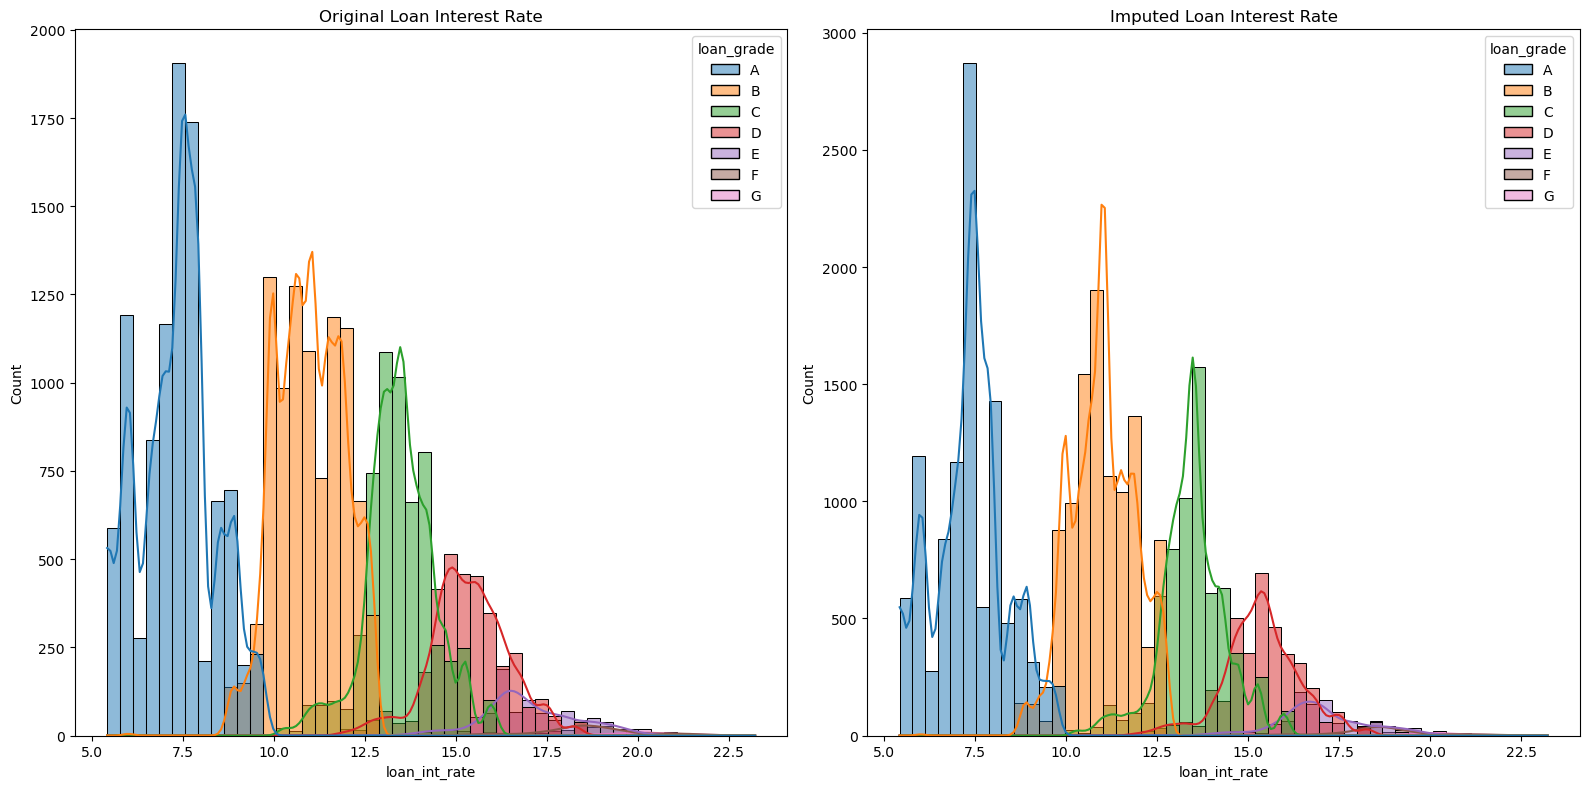

In [44]:
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

plt.figure(figsize=(16,8))

# -------------------
# 1. Original Loan Interest Rate
# -------------------
plt.subplot(1,2,1)
sns.histplot(data=df, x='loan_int_rate', hue='loan_grade', hue_order=grade_order, kde=True)
plt.title('Original Loan Interest Rate')

# -------------------
# 2. Imputed Loan Interest Rate
# -------------------
plt.subplot(1,2,2)
sns.histplot(data=lab_enc_imputed_full, x='loan_int_rate', hue='loan_grade', hue_order=grade_order, kde=True)
plt.title('Imputed Loan Interest Rate')


plt.tight_layout()
save_fig("data after MICE (lab_enc_loan_interest_rate)")
plt.show()

So from this it is ok that we can go with the MICE imputation since the distribution is not affected.
But make sure to make all the features to numeric before imputation.

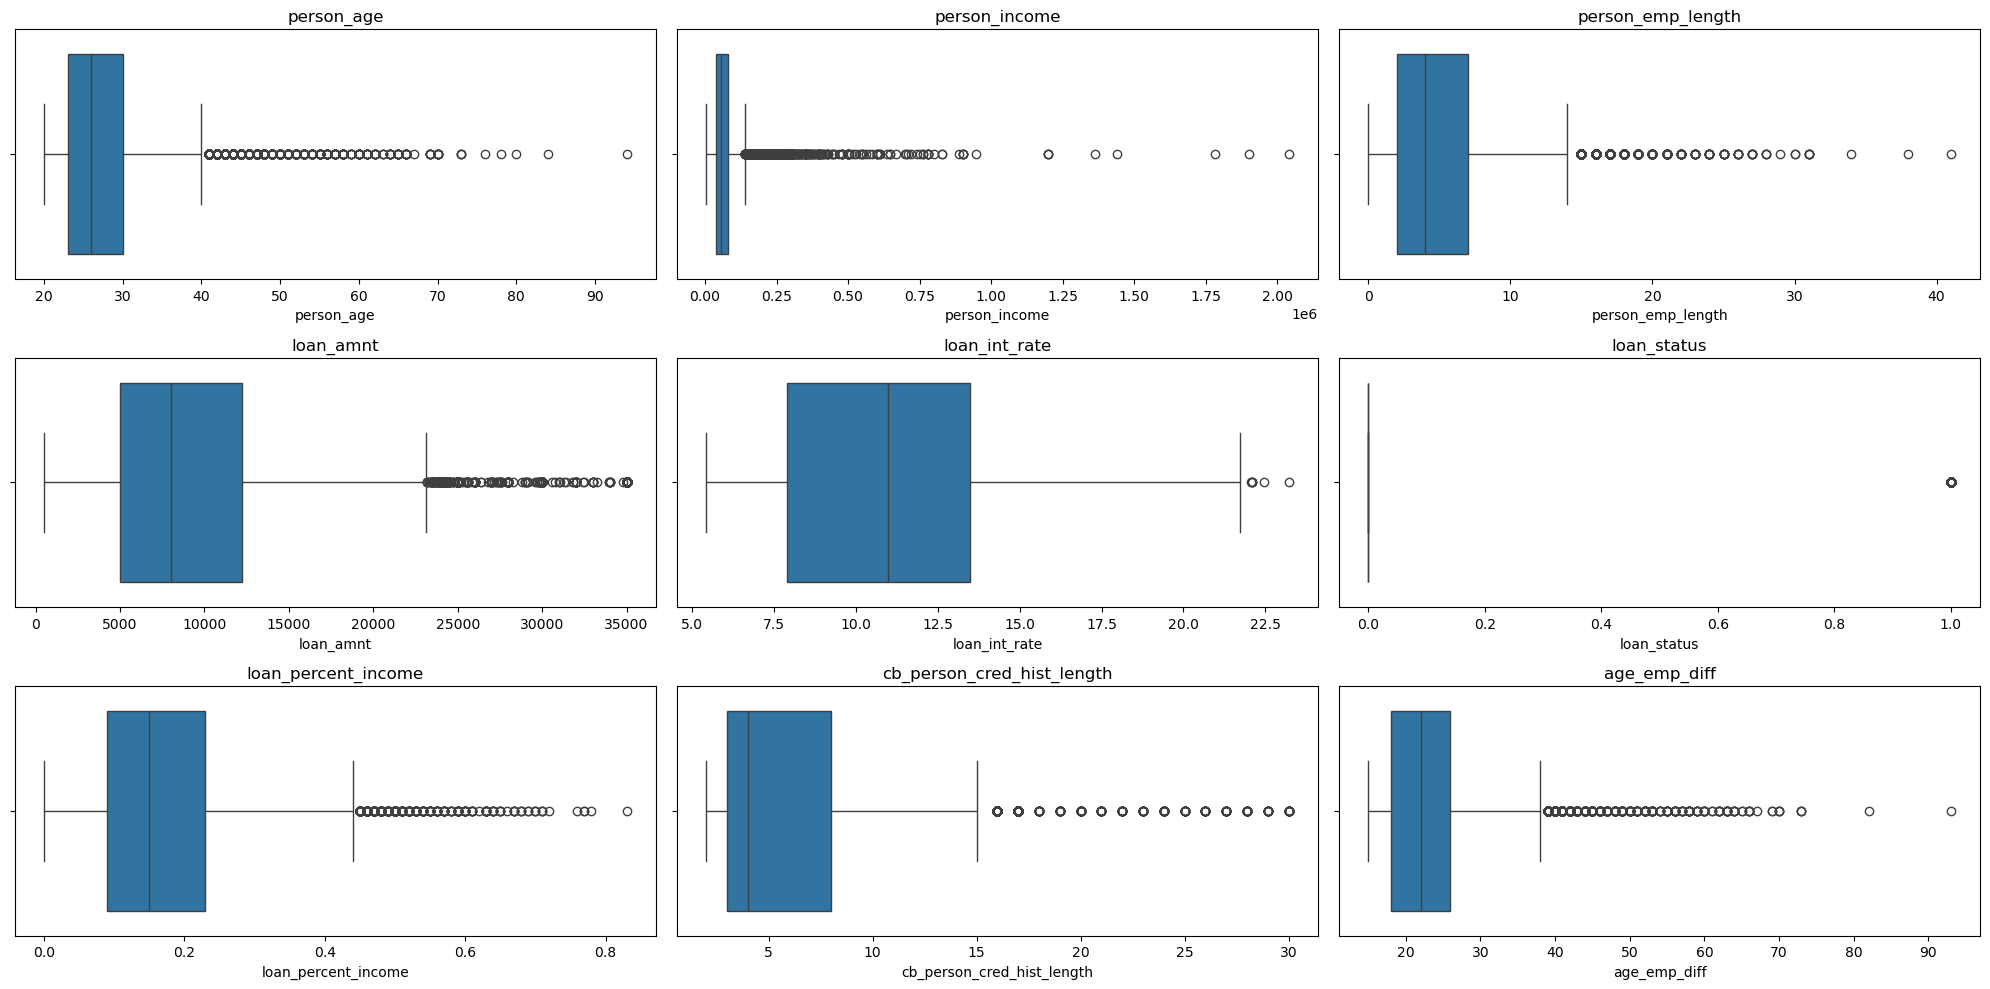

In [45]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(20,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)  
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()

plt.show()

There are may outliers so why scaling we can use the robust scaler.

In [46]:
df_copy_imputed = pd.concat([train_df, test_df], ignore_index=True)
df_copy_imputed['loan_int_rate'] = lab_enc_imputed_full['loan_int_rate']
df_copy_imputed['person_emp_length'] = lab_enc_imputed_full['person_emp_length']
df_copy_imputed = df_copy_imputed.drop(columns=['age_emp_diff'])
df_copy_imputed.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,36,72800,RENT,1.0,VENTURE,A,12000,7.66000,0,0.16,N,12
1,24,45000,OWN,8.0,HOMEIMPROVEMENT,A,10000,7.34708,0,0.22,N,3
2,23,92000,MORTGAGE,0.0,EDUCATION,B,12950,9.96000,0,0.14,N,2
3,47,178000,OWN,31.0,VENTURE,B,9000,10.99000,0,0.05,N,17
4,31,64000,MORTGAGE,4.0,DEBTCONSOLIDATION,C,5100,13.22000,1,0.08,N,10


In [47]:
df_copy_imputed.info()

<class 'pandas.DataFrame'>
RangeIndex: 32409 entries, 0 to 32408
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32409 non-null  int64  
 1   person_income               32409 non-null  int64  
 2   person_home_ownership       32409 non-null  str    
 3   person_emp_length           32409 non-null  float64
 4   loan_intent                 32409 non-null  str    
 5   loan_grade                  32409 non-null  str    
 6   loan_amnt                   32409 non-null  int64  
 7   loan_int_rate               32409 non-null  float64
 8   loan_status                 32409 non-null  int64  
 9   loan_percent_income         32409 non-null  float64
 10  cb_person_default_on_file   32409 non-null  str    
 11  cb_person_cred_hist_length  32409 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [48]:
num_cols = df_copy_imputed.select_dtypes(include=['int64', 'float64']).columns

skewness = df_copy_imputed[num_cols].skew()
print(skewness)

person_age                    1.942359
person_income                 9.777874
person_emp_length             1.294336
loan_amnt                     1.191489
loan_int_rate                 0.209351
loan_status                   1.361056
loan_percent_income           1.063283
cb_person_cred_hist_length    1.657991
dtype: float64


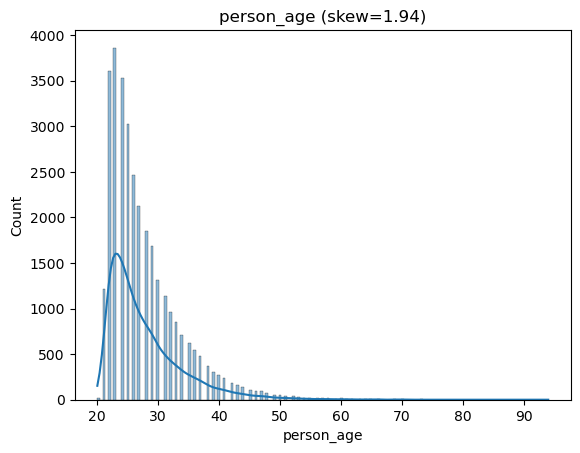

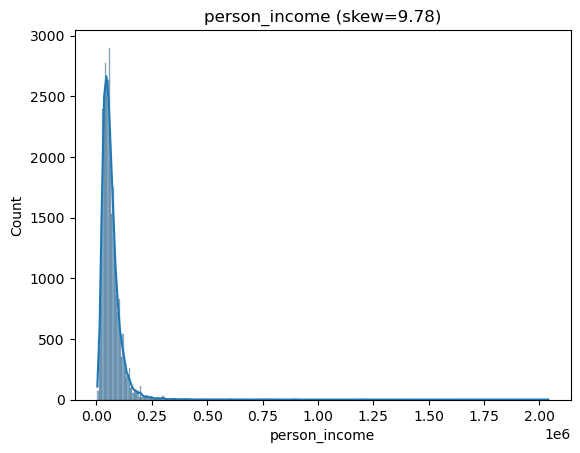

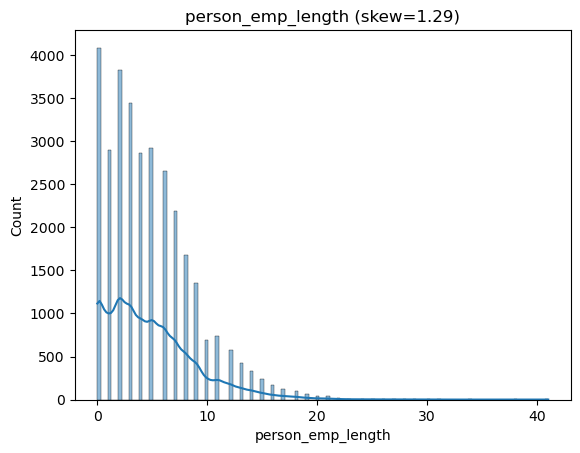

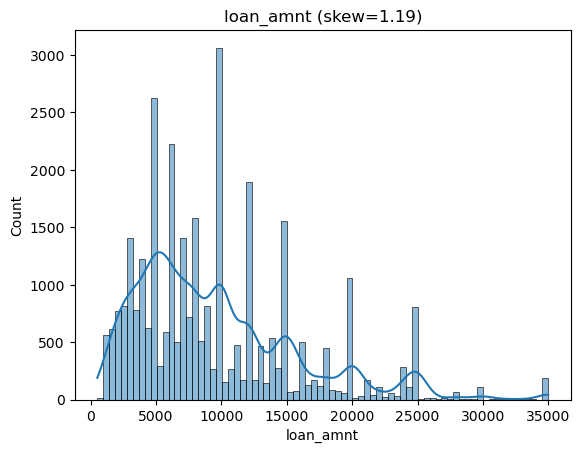

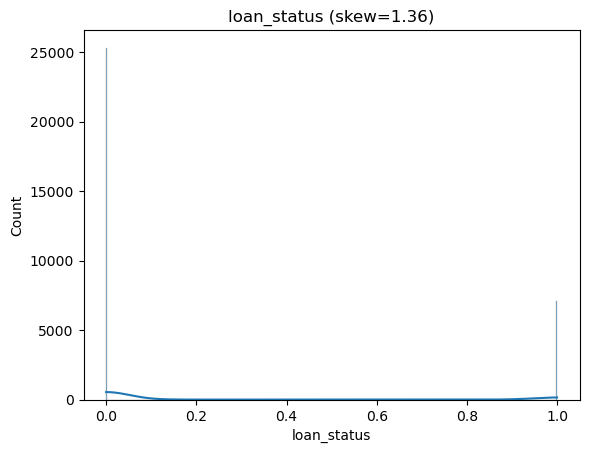

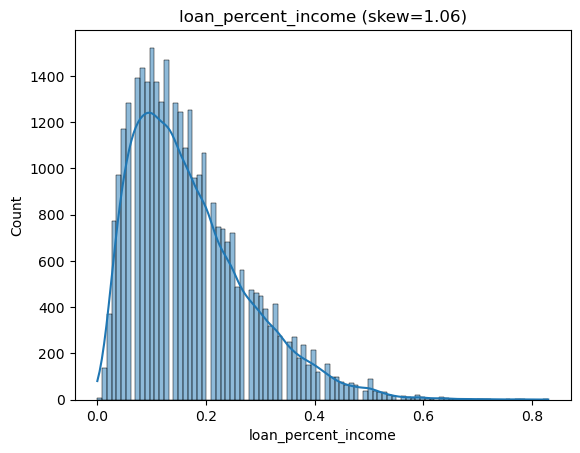

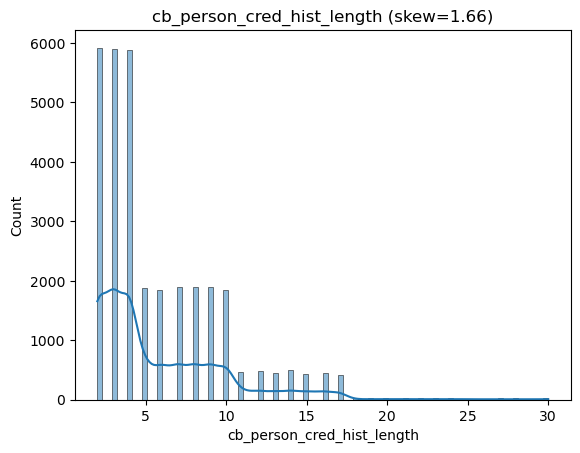

In [49]:
skewed_cols = skewness[abs(skewness) > 1].index

for col in skewed_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} (skew={skewness[col]:.2f})')
    plt.show()

In [50]:
skewed_cols = skewness[abs(skewness) > 1.5].index
skewed_cols

Index(['person_age', 'person_income', 'cb_person_cred_hist_length'], dtype='str')

Also as the 3 of the numeric column are skewed way too much we can apply the log transform to those columns

## Select and Train the Model

### Libraries

In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from collections import Counter
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.impute import IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn import config_context
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_auc_score, roc_curve

In [52]:
df = pd.read_csv(
    r"C:\Users\USER\ipnyb files\Machine Learning\Ensemble methods\datasets\credit_risk_dataset.csv"
)
df = df.drop_duplicates(keep="last")

condition = (df['person_age'] > 100) | (df['person_emp_length'] > 60)

df = df.drop(df[condition].index)

X = df.drop(columns=['loan_status']) 
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

### Preprocessing pipeline

In [53]:

numeric_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'age_emp_diff'
]

ordinal_cols = ['loan_grade']

nominal_cols = [
    'person_home_ownership',
    'loan_intent',
    'cb_person_default_on_file'
]

skewed_cols = ['person_age', 'person_income', 'cb_person_cred_hist_length']


encoding = ColumnTransformer([
    ('ord', OrdinalEncoder(categories=[['A','B','C','D','E','F','G']]), ordinal_cols),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols)
], remainder='passthrough', verbose_feature_names_out=False)


log_transformer = ColumnTransformer([
    ('log', FunctionTransformer(np.log1p), skewed_cols)
], remainder='passthrough')



preprocessing_pipeline = Pipeline([
    ('encoding', encoding),
    ('imputation', IterativeImputer(random_state=42)),
    ('log_transform', log_transformer)
])

In [54]:
with config_context(transform_output="pandas"):
    X_train_transformed = preprocessing_pipeline.fit_transform(X_train, y_train)
    X_test_transformed = preprocessing_pipeline.transform(X_test)

X_train_transformed.head()
X_test_transformed.head()

,log__person_age,log__person_income,log__cb_person_cred_hist_length,remainder__loan_grade,remainder__person_home_ownership_MORTGAGE,remainder__person_home_ownership_OTHER,remainder__person_home_ownership_OWN,remainder__person_home_ownership_RENT,remainder__loan_intent_DEBTCONSOLIDATION,remainder__loan_intent_EDUCATION,remainder__loan_intent_HOMEIMPROVEMENT,remainder__loan_intent_MEDICAL,remainder__loan_intent_PERSONAL,remainder__loan_intent_VENTURE,remainder__cb_person_default_on_file_N,remainder__cb_person_default_on_file_Y,remainder__person_emp_length,remainder__loan_amnt,remainder__loan_int_rate,remainder__loan_percent_income
16818,3.178054,11.002117,1.098612,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0,25000.0,10.25,0.42
24074,3.465736,11.156265,2.397895,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,9.0,18000.0,8.90,0.26
27233,3.332205,11.661354,2.079442,3.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,4.0,25000.0,13.36,0.22
15494,3.258097,11.849405,1.386294,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,35000.0,10.59,0.25
4829,3.258097,10.491302,1.609438,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,13750.0,13.22,0.38


In [55]:
y_train.value_counts()

loan_status
0    20257
1     5670
Name: count, dtype: int64

In [ ]:
def evaluate_model(y_true, y_pred, class_labels, model_name=None):
    print(f"--------------------- Classification Report {model_name} ---------------------")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(cmap='Blues')
    plt.title(f"Confusion Matrix {model_name}")
    plt.show()

    


In [57]:
rf_clf1 = RandomForestClassifier(class_weight='balanced', random_state=42)

rf_clf1.fit(X_train_transformed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

--------------------- Classification Report RandomForest (Base) ---------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20257
           1       1.00      1.00      1.00      5670

    accuracy                           1.00     25927
   macro avg       1.00      1.00      1.00     25927
weighted avg       1.00      1.00      1.00     25927



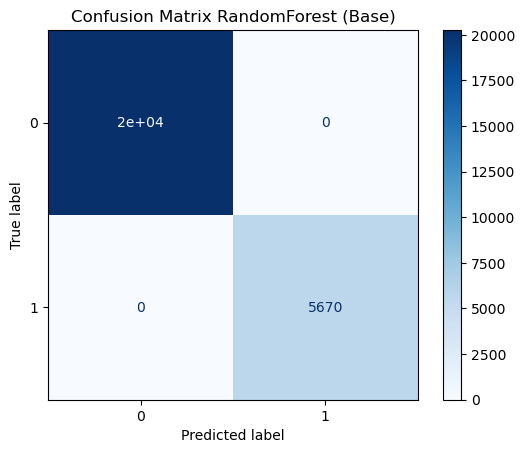

In [58]:
y_pred = rf_clf1.predict(X_train_transformed)
class_labels = rf_clf1.classes_
evaluate_model(y_train, y_pred, class_labels=class_labels, model_name="RandomForest (Base)")

--------------------- Classification Report XGBClassifier (Base) ---------------------
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     20257
           1       0.91      0.93      0.92      5670

    accuracy                           0.97     25927
   macro avg       0.95      0.96      0.95     25927
weighted avg       0.97      0.97      0.97     25927



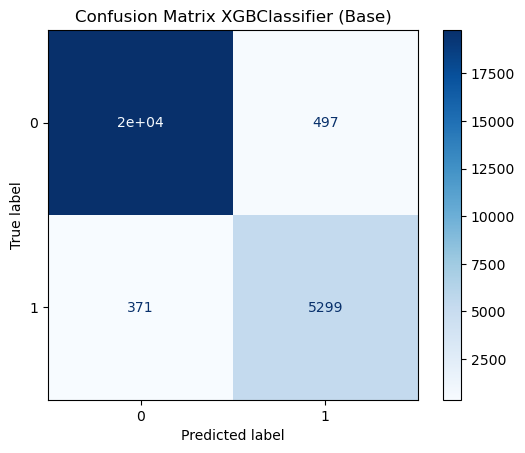

In [59]:
counter = Counter(y_train)
neg, pos = counter[0], counter[1]

scale_pos_weight = neg / pos

xgb_clf1 = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
xgb_clf1.fit(X_train_transformed, y_train)

y_pred = xgb_clf1.predict(X_train_transformed)
evaluate_model(
    y_train, y_pred, class_labels=class_labels, model_name="XGBClassifier (Base)"
)

In [60]:
cross_val_score(xgb_clf1, X_train_transformed, y_train, cv=5, scoring="f1")

array([0.81388013, 0.81772035, 0.82252252, 0.79749104, 0.81521739])

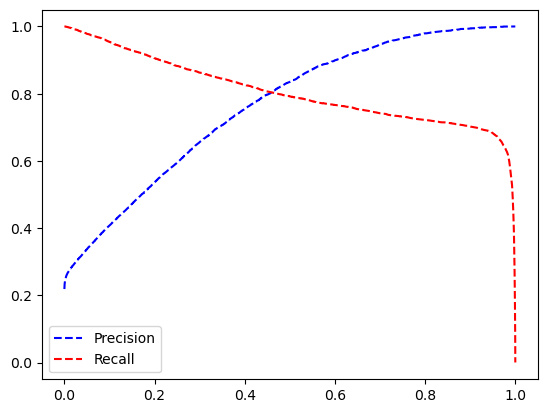

In [65]:
y_scores = cross_val_predict(xgb_clf1, X_train_transformed, y_train, method='predict_proba', cv=5)[:,1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "r--", label="Recall")
plt.legend()
plt.show()

In [67]:
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print("Best Threshold (F1):", best_threshold)
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])

Best Threshold (F1): 0.71412945
Precision: 0.9533879035925421
Recall: 0.7395061728395061


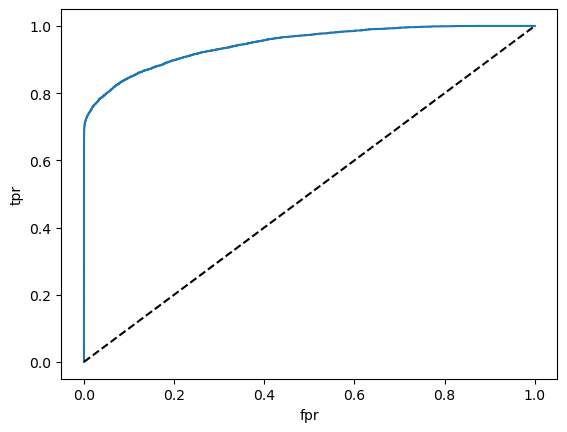

In [71]:
fpr, tpr, thresholds = roc_curve(y_train, y_scores)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], "k--")
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.show()

In [72]:
roc_auc_score(y_train, y_scores)

0.9461859592769072

# Review

In [83]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier





In [78]:
rdf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')
xb_clf = XGBClassifier()

In [81]:
sk_fold = StratifiedKFold(n_splits=4)
print("RandomForestClassifier CV score")
rf_cv_scores = cross_val_score(rdf_clf, X_train_transformed, y_train, cv=sk_fold)
print(rf_cv_scores.mean())


print("XGBClassifier CV score")
xb_cv_scores = cross_val_score(xb_clf, X_train_transformed, y_train, cv=sk_fold)
print(xb_cv_scores.mean())

RandomForestClassifier CV score
0.9320785948207089
XGBClassifier CV score
0.9356269657000853


In [85]:
param_grid = {
    "max_depth":[None, 5, 10, 20, 25, 50],
    "min_samples_split":[2,4,5,7,10],
    "max_leaf_nodes":[None, 2,5, 10, 15, 20]
}

grid = GridSearchCV(rdf_clf, param_grid=param_grid, cv=sk_fold, n_jobs=-1)
grid.fit(X_train_transformed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_leaf_nodes': [None, 2, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [87]:
print("RandomForestClassifier Tuned CV score")
rf_tuned_cv_scores = cross_val_score(grid.best_estimator_, X_train_transformed, y_train, cv=sk_fold)
print(rf_tuned_cv_scores.mean())

RandomForestClassifier Tuned CV score
0.9326957597222099


In [82]:
y_train.value_counts()

loan_status
0    20257
1     5670
Name: count, dtype: int64